# Facial Expression Recognition with PyTorch

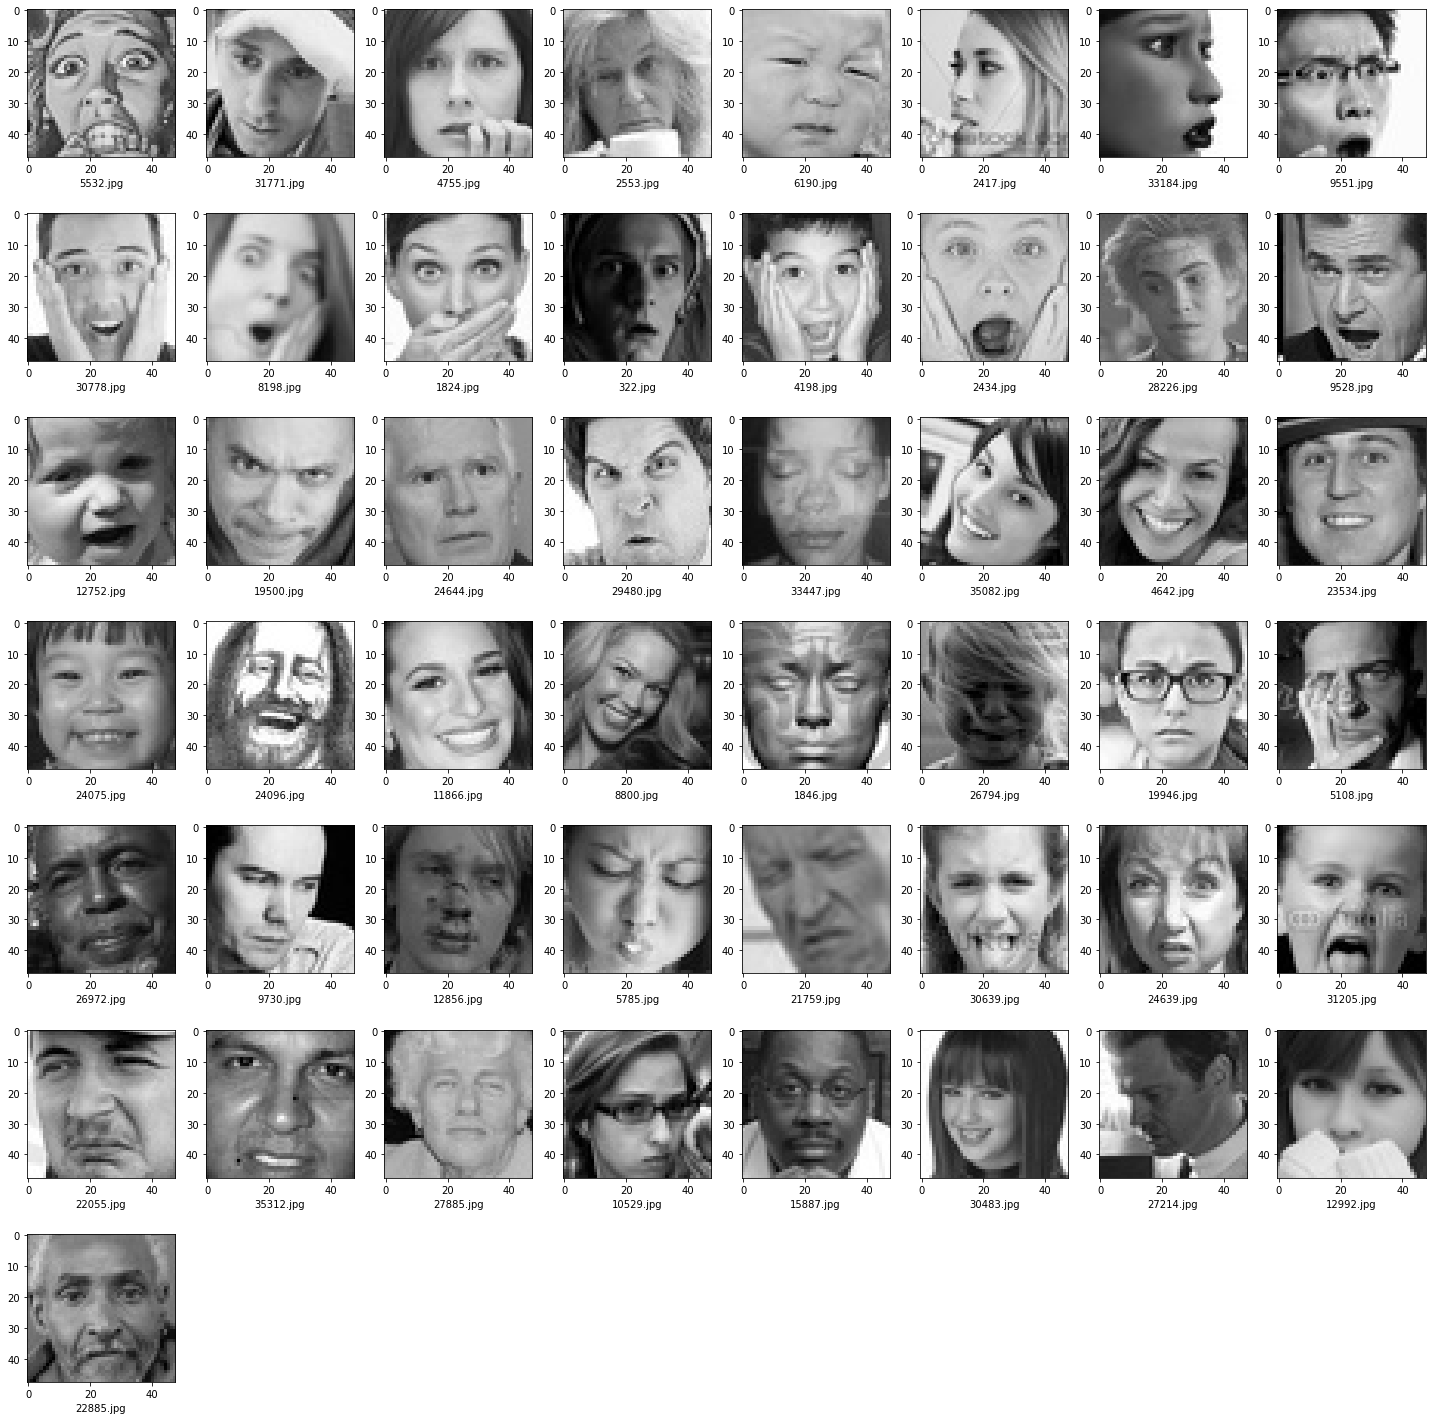

# Install libraries, packages and dataset

In [1]:
!git clone https://github.com/parth1620/Facial-Expression-Dataset.git
!pip install -U albumentations
!pip install timm
!pip install --upgrade opencv-contrib-python

Cloning into 'Facial-Expression-Dataset'...
remote: Enumerating objects: 34052, done.
remote: Total 34052 (delta 0), reused 0 (delta 0), pack-reused 34052 (from 1)
Receiving objects: 100% (34052/34052), 52.31 MiB | 50.97 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Updating files: 100% (35887/35887), done.


Dataset: https://www.kaggle.com/jonathanoheix/face-expression-recognition-dataset

# Imports

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random

# Configurations

In [3]:
TRAIN_IMG_FOLDER_PATH = '/content/Facial-Expression-Dataset/train/'
VALID_IMG_FOLDER_PATH = '/content/Facial-Expression-Dataset/validation/'

LR = 0.001
BATCH_SIZE = 32
EPOCHS = 15

DEVICE = 'cuda'
MODEL_NAME = 'efficientnet_b0'

# Load Dataset

In [4]:
from torchvision.datasets import ImageFolder
from torchvision import transforms as T

In [5]:
train_augs = T.Compose([
    T.RandomHorizontalFlip(p = 0.5),
    T.RandomRotation(degrees = (-20, +20)),
    T.ToTensor()
])

valid_augs = T.Compose([
    T.ToTensor()
])

In [6]:
trainset = ImageFolder(TRAIN_IMG_FOLDER_PATH, transform = train_augs)
validset = ImageFolder(VALID_IMG_FOLDER_PATH, transform = valid_augs)

In [7]:
print(f"Total no. of examples in trainset : {len(trainset)}")
print(f"Total no. of examples in validset : {len(validset)}")

Total no. of examples in trainset : 28821
Total no. of examples in validset : 7066


In [8]:
print(trainset.class_to_idx)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


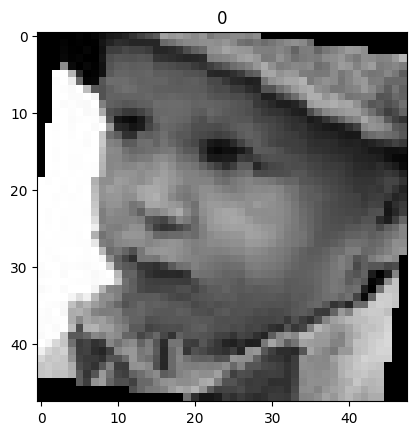

In [9]:
image, label = trainset[20]
plt.imshow(image.permute(1, 2, 0))
plt.title(label)
plt.show()

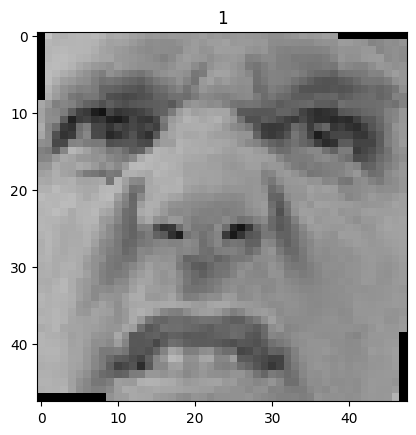

In [10]:
image, label = trainset[4000]
plt.imshow(image.permute(1, 2, 0))
plt.title(label)
plt.show()

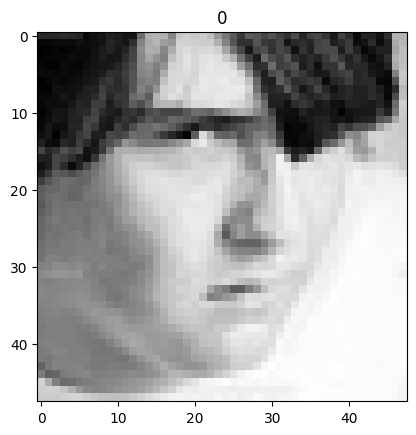

In [12]:
image, label = validset[40]
plt.imshow(image.permute(1, 2, 0))
plt.title(label)
plt.show()

# Load Dataset into Batches

In [13]:
from torch.utils.data import DataLoader

In [14]:
trainloader = DataLoader(trainset, batch_size = BATCH_SIZE, shuffle = True)
validloader = DataLoader(validset, batch_size = BATCH_SIZE)

In [15]:
print(f"Total no. of batches in trainloader : {len(trainloader)}")
print(f"Total no. of batches in validloader : {len(validloader)}")

Total no. of batches in trainloader : 901
Total no. of batches in validloader : 221


In [16]:
for images, labels in trainloader:
  break;

print(f"One image batch shape : {images.shape}")
print(f"One label batch shape : {labels.shape}")

One image batch shape : torch.Size([32, 3, 48, 48])
One label batch shape : torch.Size([32])


# Create Model

In [17]:
import timm
from torch import nn

In [18]:
class FaceModel(nn.Module):

  def __init__(self):
    super(FaceModel, self).__init__()

    self.eff_net = timm.create_model('efficientnet_b0', pretrained = True, num_classes = 7)

  def forward(self, images, labels = None):

    logits = self.eff_net(images)

    if labels != None:
      loss = nn.CrossEntropyLoss()(logits, labels)
      return logits, loss

    return logits

In [20]:
model = FaceModel()
model.to(DEVICE);

# Create Train and Eval Function

In [21]:
from tqdm import tqdm

In [22]:
def multiclass_accuracy(y_pred,y_true):
    top_p,top_class = y_pred.topk(1,dim = 1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

In [23]:
def train_fn(model, dataloader, optimizer, current_epo):

  model.train()
  total_loss = 0.0
  total_acc = 0.0
  tk = tqdm(dataloader, desc = "EPOCH" + "[TRAIN]" + str(current_epo + 1) + "/" + str(EPOCHS))

  for t, data in enumerate(tk):
    images, labels = data
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    optimizer.zero_grad()
    logits, loss = model(images, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total_acc += multiclass_accuracy(logits, labels)
    tk.set_postfix({'loss' : '%6f' %float(total_loss / (t+1)), 'acc' : '%6f' %float(total_acc / (t+1))})

  return total_loss / len(dataloader), total_acc / len(dataloader)

In [24]:
def eval_fn(model, dataloader, current_epo):

  model.eval()
  total_loss = 0.0
  total_acc = 0.0
  tk = tqdm(dataloader, desc = "EPOCH" + "[VALID]" + str(current_epo + 1) + "/" + str(EPOCHS))

  for t, data in enumerate(tk):
    images, labels = data
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    logits, loss = model(images, labels)

    total_loss += loss.item()
    total_acc += multiclass_accuracy(logits, labels)
    tk.set_postfix({'loss' : '%6f' %float(total_loss / (t+1)), 'acc' : '%6f' %float(total_acc / (t+1))})

  return total_loss / len(dataloader), total_acc / len(dataloader)

# Create Training Loop

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr = LR)

In [26]:
best_valid_loss = np.inf

for i in range(EPOCHS):
  train_loss, train_acc = train_fn(model, trainloader, optimizer, i)
  valid_loss, valid_acc = eval_fn(model, validloader, i)

  if valid_loss < best_valid_loss:
    torch.save(model.state_dict(), 'best-weights.pt')
    print("SAVED-BEST-WEIGHTS")
    best_valid_loss = valid_loss

EPOCH[VALID]1/15: 100%|██████████| 221/221 [00:05<00:00, 36.91it/s, loss=1.364895, acc=0.481607]


SAVED-BEST-WEIGHTS


EPOCH[VALID]2/15: 100%|██████████| 221/221 [00:06<00:00, 36.25it/s, loss=1.191074, acc=0.548599]


SAVED-BEST-WEIGHTS


EPOCH[VALID]3/15: 100%|██████████| 221/221 [00:06<00:00, 35.65it/s, loss=1.123214, acc=0.584167]


...

EPOCH[VALID]13/15: 100%|██████████| 221/221 [00:06<00:00, 35.39it/s, loss=0.978397, acc=0.645623]


SAVED-BEST-WEIGHTS


EPOCH[VALID]14/15: 100%|██████████| 221/221 [00:05<00:00, 39.73it/s, loss=0.974957, acc=0.648277]


SAVED-BEST-WEIGHTS


EPOCH[VALID]15/15: 100%|██████████| 221/221 [00:05<00:00, 38.08it/s, loss=1.018092, acc=0.640304]


# Inference

In [27]:
def view_classify(img, ps):

    classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

    ps = ps.data.cpu().numpy().squeeze()
    img = img.numpy().transpose(1,2,0)

    fig, (ax1, ax2) = plt.subplots(figsize=(5,9), ncols=2)
    ax1.imshow(img)
    ax1.axis('off')
    ax2.barh(classes, ps)
    ax2.set_aspect(0.1)
    ax2.set_yticks(classes)
    ax2.set_yticklabels(classes)
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

    return None

Viewing index: 6300


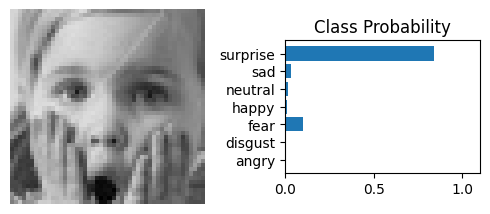

In [45]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)

Viewing index: 6255


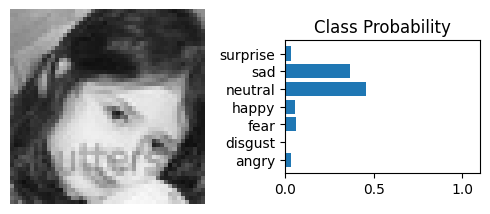

In [46]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)

Viewing index: 1292


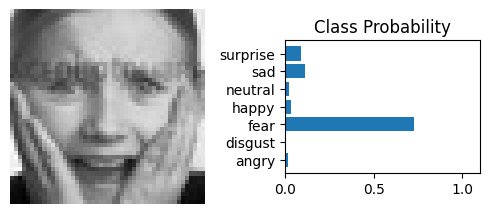

In [47]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)

Viewing index: 3536


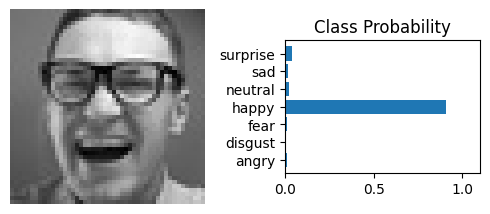

In [48]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)

Viewing index: 225


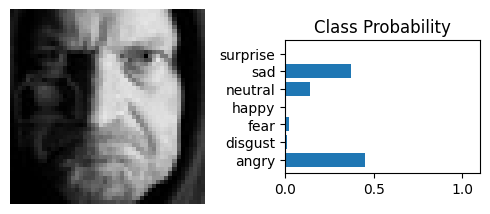

In [49]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)

Viewing index: 3612


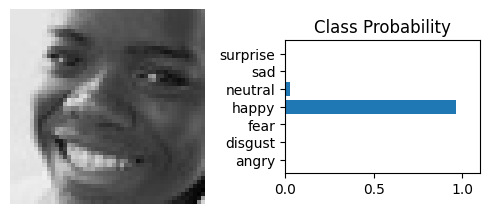

In [50]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)

Viewing index: 1781


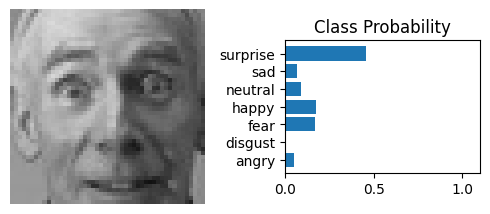

In [51]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)

Viewing index: 2571


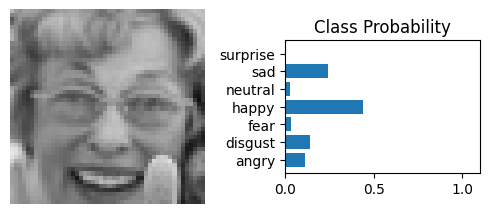

In [52]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)

Viewing index: 2515


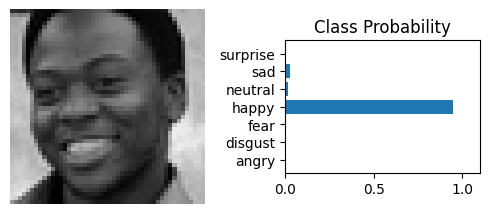

In [53]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)

Viewing index: 6863


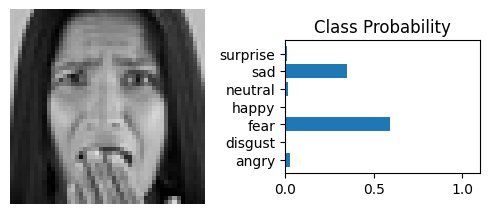

In [54]:
# Load the best weights
model.load_state_dict(torch.load('best-weights.pt'))

# Choose a random image from the validation set
idx = random.randint(0, len(validset) - 1)
image, label = validset[idx]

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    ps = torch.softmax(logits, dim=1)

# Visualize the prediction
print(f"Viewing index: {idx}")
view_classify(image, ps)